# Lecture 16 — The Full Equation of State: Species Slots & the Convective Heat Capacity

*Stellar Spectroscopy from Scratch — rebuilding the physics of ATLAS and SYNTHE from first principles*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision.*

*Every result in this book is checked against reference values computed with [**pykurucz**](https://arxiv.org/abs/2603.11693) — a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE — shipped beside the lectures as small data files, so the notebooks need only NumPy to run.*

---

**Why this lecture exists — and where it sits.** This is the closing lecture of Part VI, and of the book. Lecture 15 switched the line blanket on and reran the convergence engine until it reached the real Sun — but its deposit kernel *consumed* a per-iteration equation-of-state state (the populations the continuum needs, the Doppler widths and species populations the deposit indexes, the continuum-cutoff table, the convective heat-capacity samples) that it still read from a reference file, computed once by the production code. Lecture 11 leaned on the same convenience. That reference state is the **last borrowed intermediate** in the whole book. This lecture removes it: it builds, from scratch, every piece of state the converged line-blanketed atmosphere needs each iteration, then hands it back to Lecture 15's loop — honest inputs (the atomic-data tables and the line catalog) in, a converged solar model out, with nothing read but the comparison target.

So Part VI has two halves that interlock. **Lecture 15** is the new *physics* — the line-deposit kernel and the back-warming it drives. **This lecture** is the *state that physics runs on* — the multi-element equation of state that Lecture 15's deposit and Lecture 11's convergence both quietly assumed. Built here, the dependency closes: the deposit indexes slots this lecture fills, and the convergence steps a temperature this lecture's heat capacity makes adiabatically correct. Together they are the **atmosphere built genuinely from scratch** — the other half of the "end to end" that Lecture 14 made for the spectrum.

By "the full equation of state" we mean the *full ATLAS/SYNTHE per-iteration state* — the ideal Saha–Boltzmann ionization equilibrium of Lecture 2 across all species, plus the derived per-slot quantities the opacity engines read. It is "full" in the sense of *complete for the Kurucz atmosphere pipeline*, not a general non-ideal stellar equation of state (no pressure ionization, degeneracy, or Coulomb corrections — none of which matter at photospheric densities).

**Learning objectives.** By the end of this lecture you will be able to:

- Extend Lecture 2's single-element Saha–Boltzmann equation of state to the **multi-element "special-slot" layout** — the flat array, indexed by a species code, that holds the population of every ion of every element the opacity engines read. This is the `POPSALL` array of ATLAS.
- Build the **Doppler widths** `dopple` and the population-per-Doppler-width-per-density `xnfdop` for every species slot, and the **van der Waals perturber number** `txnxn` the line-damping parameter needs.
- Construct the **continuum-cutoff table** `tabcont` the deposit keys off, and complete Lecture 3's continuous opacity with the **far-UV metal bound-free forest** that dominates the 90–150 nm continuum at the hot deep base.
- Compute the **convective heat capacity** from finite-difference equation-of-state samples, and see *why the gas internal energy must carry the ionization energy*.
- Assemble these into the **per-iteration state** the line-blanketed convergence of Lecture 15 consumes, and confirm each piece reproduces the production state to the documented floor.

## Setup and the honest inputs

Everything this lecture computes is a function of the atmosphere's $(T,\rho x, P)$ structure plus
the **honest input data tables** — the same files the production code reads: the partition-function
data of Lecture 2 (`pfsaha_inputs.npz`), the atomic masses (`atomic_masses.npz`), the static
continuum-cutoff grid (`wavetab_grid.npz`), the molecular data of Lecture 13 (`molecules.dat`), and
the continuum cross-section tables of Lecture 3 (`leankurucz_tables.npz`). The from-scratch routines
that assemble them live beside the lectures (`eos_fromscratch`, `continuum_fromscratch`,
`continuum_faruv`, `molecular_fromscratch`); we import and read them here so each cell stays short,
and we show the load-bearing physics inline. The benchmark target `reference/eos_state_ref.npz` is
the production per-iteration state at the Sun's converged structure — used only to *check*, never
read as an answer.

In [1]:
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})
sys.path.insert(0, str(pathlib.Path("..") / "_pipeline"))     # the from-scratch EOS modules
import eos_fromscratch as EOS

REF = pathlib.Path("..") / "reference"
S = np.load(REF / "eos_state_ref.npz")
T = S["T"]; rhox = S["rhox"]; P = S["P"]; xabund = S["xabund"]; wtmole = float(S["wtmole"])
print(f"the Sun's converged structure: {T.size} layers")
print(f"  surface T = {T[0]:.1f} K   base T = {T[-1]:.1f} K   base RHOX = {rhox[-1]:.3f} g/cm^2")

the Sun's converged structure: 80 layers
  surface T = 3696.3 K   base T = 11425.0 K   base RHOX = 12.144 g/cm^2


## 1. The special-slot population layout (`POPSALL`)

Lecture 2 solved the Saha–Boltzmann equation of state for a single element: given $(T, n_e)$ it
returned the partition function and the ionization fractions of each ion stage. The opacity engines,
though, need the population of *every ion stage the Kurucz layout carries*, for every element, laid
out in a single flat array that they index by a compact **species code** — the same code each line in
the catalog carries. ATLAS calls the routine that fills this array `POPSALL`, and the array itself is
the heart of the per-iteration state.

The layout is a fixed schedule. Element $Z$'s ion stages occupy a contiguous block of slots; the
blocks are packed *triangularly* for $Z\le30$ (hydrogen gets 2 slots, helium 3, lithium 4, …) and on
a stride-5 grid from slot 496 for $Z\ge31$ (the heavy elements keep only their first few stages, the
ones that populate at photospheric temperatures). A line's species code `ielion` names the Kurucz slot
number $\texttt{nelion}=|\texttt{ielion}|//10$ (a 1-based Fortran index); the corresponding NumPy
column is $\texttt{nelion}-1$. So the first job is to run the Lecture-2 equation of state across all
99 elements and pack the results into this flat layout. Our `eos_fromscratch.popsall` does exactly
that — it is Lecture 2's `run_pfsaha`/`run_nelect`, vectorised over depth and assembled into the slot
array. Let us run it on the Sun and look at what it produces.

In [2]:
tab = EOS.EOSTables.from_npz(REF / "pfsaha_inputs.npz")    # Lecture-2 atomic data (honest input)
pa = EOS.popsall(T, P, xabund, tab=tab, wtmole=wtmole)     # the multi-element EOS, all elements

print(f"electron density n_e: surface {pa.xne[0]:.3e}   base {pa.xne[-1]:.3e}  cm^-3")
print(f"mass density rho:     surface {pa.rho[0]:.3e}   base {pa.rho[-1]:.3e}  g/cm^3")
print(f"population_per_ion shape {pa.population_per_ion.shape}  (depth x ion-stage x element)")

# check: the from-scratch electron density + density reproduce the production state
def relmax(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float); m = b != 0
    return float((np.abs(a - b) / np.maximum(np.abs(b), 1e-300))[m].max()) if m.any() else 0.0
print(f"\nn_e   vs production: max|rel| = {relmax(pa.xne, S['xne']):.2e}")
print(f"rho   vs production: max|rel| = {relmax(pa.rho, S['rho']):.2e}")
print(f"H I/H II populations vs production: max|rel| = {relmax(pa.xnfph, S['xnfph']):.2e}")

electron density n_e: surface 2.415e+09   base 2.175e+16  cm^-3
mass density rho:     surface 5.571e-11   base 3.971e-07  g/cm^3
population_per_ion shape (80, 6, 139)  (depth x ion-stage x element)

n_e   vs production: max|rel| = 5.31e-16
rho   vs production: max|rel| = 0.00e+00
H I/H II populations vs production: max|rel| = 2.07e-16


The electron density, the mass density, and the per-ion populations reproduce the production
equation of state to the float-64 floor — this is the Lecture-2 physics, now run for all elements and
packed into the flat layout the opacity engines read. The Saha cascade and the charge-balance
iteration are exactly those of Lecture 2; only the bookkeeping is new.

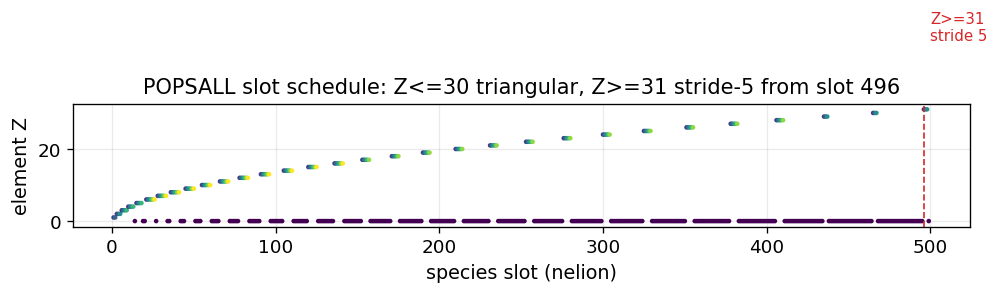

a line with species code ielion deposits into slot |ielion|//10 - 1 (0-based)


In [3]:
# the slot layout: how many slots each element gets, and where the line deposit reads them.
z_of, ion_of = EOS._build_nelion_maps()
fig, ax = plt.subplots(figsize=(8.5, 3.4))
nel = np.arange(1, 500)
ax.scatter(nel, z_of[nel], s=3, c=ion_of[nel], cmap="viridis")
ax.set_xlabel("species slot (nelion)"); ax.set_ylabel("element Z")
ax.set_title("POPSALL slot schedule: Z<=30 triangular, Z>=31 stride-5 from slot 496")
ax.axvline(496, color="C3", lw=1, ls="--"); ax.text(500, 50, "Z>=31\nstride 5", color="C3", fontsize=9)
fig.tight_layout(); plt.show()
print("a line with species code ielion deposits into slot |ielion|//10 - 1 (0-based)")

## 2. Doppler widths and the van der Waals perturber number

Each line in Lecture 15 needed three per-depth numbers: the line-center opacity, the Doppler width,
and the damping parameter. The Doppler width is thermal-plus-microturbulent,

$$\frac{\Delta\lambda_{\rm D}}{\lambda} = \frac{1}{c}\sqrt{\frac{2k_{\rm B}T}{m}+v_{\rm turb}^2},$$

the *same* width for every ion stage of an element (it depends only on the atomic mass $m$). The line
deposit reads it per species slot as `dopple`, and reads the line-center normalisation as
`xnfdop` $= n_{\rm species}/(\Delta\nu_{\rm D}\,\rho)$ — the **species** population (the ion or
molecular number density, before any per-line factor) divided by the Doppler width and the density,
the combination that carries the Voigt peak normalisation. Each individual line later supplies its own
lower-level Boltzmann factor and $gf$ on top of this slot value (exactly the deposit of Lecture 15).
We build both from the populations of section 1 and the atomic masses.

The damping parameter's van der Waals term needs one more quantity: the **neutral perturber number**,

$$\texttt{txnxn} = \bigl(n_{\rm H\,I} + 0.42\,n_{\rm He\,I} + 0.85\,n_{\rm H_2}\bigr)\left(\frac{T}{10^4}\right)^{0.3},$$

the weighted density of the neutral perturbers (hydrogen, helium, molecular hydrogen) that broaden a
line by collisions, with the standard $T^{0.3}$ temperature scaling. The molecular-hydrogen number
comes from the $\mathrm{H_2}$ dissociation equilibrium and is switched off above 9000 K where
$\mathrm{H_2}$ is dissociated.

In [4]:
vturb = S["vturb"]; atmass = np.load(REF / "atomic_masses.npz")["atmass"]   # honest inputs
dop3 = EOS.compute_doppler_per_ion(T, vturb, atmass)                # (depth, ion, element)
xnfdop, dopple = EOS.build_xnfdop_dopple_per_nelion(pa.population_per_ion, dop3, pa.rho)
txnxn = EOS.compute_txnxn(T, pa.xnf_h, pa.xnf_he1)

print(f"xnfdop / dopple shape {xnfdop.shape}  (depth x species slot)")
print(f"nonzero atomic species slots: {int(np.count_nonzero(xnfdop.sum(0)))}")
print(f"\ndopple vs production: max|rel| = {relmax(dopple, S['dopple']):.2e}")
print(f"xnfdop vs production: max|rel| = {relmax(xnfdop, S['xnfdop']):.2e}")
print(f"txnxn  vs production: max|rel| = {relmax(txnxn, S['txnxn']):.2e}")

xnfdop / dopple shape (80, 1006)  (depth x species slot)
nonzero atomic species slots: 356

dopple vs production: max|rel| = 0.00e+00
xnfdop vs production: max|rel| = 5.70e-14
txnxn  vs production: max|rel| = 0.00e+00


All three reproduce the production state to the float-64 floor. These per-slot arrays are
exactly what the Lecture-15 line deposit indexes by species code to set each line's height, width,
and damping.

## 3. The continuum-cutoff table — and completing the far-UV continuum

The line deposit of Lecture 15 walks each line's wings outward only as long as the line opacity stays
above the local continuum; the threshold it compares against is the **continuum-cutoff table**
`tabcont`, the continuum opacity sampled on a coarse 344-point wavelength grid and scaled,
$\texttt{tabcont}=(\kappa^{\rm cont}+\sigma^{\rm cont})\cdot10^{-3}/\,\texttt{stim}$, where
$\texttt{stim}=1-e^{-hc/\lambda kT}$ is the stimulated-emission correction. Building it is a direct
application of Lecture 3's continuous opacity at the 344 cutoff wavelengths.

There is a subtlety the deep base exposes. Lecture 3's continuum was validated in the optical
(500–510 nm), and there it is exact. But the Rosseland mean is a *harmonic* opacity mean weighted by
$\partial B_\lambda/\partial T$, so at the hot base (11425 K) — where that weighting function peaks
near 250 nm — the relatively transparent **far-ultraviolet** windows carry a disproportionate share of
the mean, and missing opacity there matters most. In the 90–150 nm window the dominant continuous
opacity is the **metal bound-free forest** — the carbon, magnesium, silicon, aluminium and iron
photoionisation edges. Lecture 3 kept only each metal's single *optical* edge (a safe truncation for
the optical window); for the deep base we must restore the full far-UV series. At 100 nm and 11425 K
the carbon I bound-free alone supplies $\sim95\%$ of the continuum. The module `continuum_faruv` adds this forest (the multi-edge level series, the
Luo–Pradhan resonances, and the Kramers–Gaunt free-free), reusing Lecture 3's own Karzas–Latter
cross-section. We compute the continuum *with* the far-UV forest and build `tabcont`.

In [5]:
import continuum_fromscratch as CF      # bridges the EOS to Lecture-3 KAPP + builds tabcont
freq = 2.99792458e17 / np.array([100.0, 150.0, 250.0, 505.0])
ac_opt, _ = CF.compute_continuum(freq, pa, T, pa.rho, pa.xne, faruv=False)  # optical edges only
ac_uv,  _ = CF.compute_continuum(freq, pa, T, pa.rho, pa.xne, faruv=True)   # + far-UV forest
print("continuum at the base (11425 K), optical-only vs with the far-UV metal-bf forest:")
for i, w in enumerate([100, 150, 250, 505]):
    print(f"  {w:4d} nm : {ac_opt[-1,i]:.3e} -> {ac_uv[-1,i]:.3e}  ({ac_uv[-1,i]/ac_opt[-1,i]:.1f}x)")
print("the far-UV forest lifts the 100 nm continuum ~25x at the hot base; the 505 nm optical is unchanged")

continuum at the base (11425 K), optical-only vs with the far-UV metal-bf forest:
   100 nm : 3.266e+01 -> 8.036e+02  (24.6x)
   150 nm : 7.261e+01 -> 9.845e+01  (1.4x)
   250 nm : 2.769e+02 -> 2.785e+02  (1.0x)
   505 nm : 1.928e+02 -> 1.930e+02  (1.0x)
the far-UV forest lifts the 100 nm continuum ~25x at the hot base; the 505 nm optical is unchanged


In [6]:
# build the cutoff table (with the far-UV forest) and check it vs the production tabcont.
os_start = float(np.load(REF / "lineblanket_ref.npz", allow_pickle=True)["waveset_nm"][0])
tabcont, iwavetab = CF.build_tabcont(pa, T, pa.rho, pa.xne, os_start)
ref = np.load(REF / "lineblanket_ref.npz", allow_pickle=True)
mtab = ref["tabcont"] != 0
rel_tab = np.abs(tabcont.astype(float) - ref["tabcont"].astype(float)) / np.maximum(np.abs(ref["tabcont"]), 1e-30)
print(f"tabcont shape {tabcont.shape}   median|rel| vs production = {np.median(rel_tab[mtab]):.2e}")
print(f"iwavetab matches production: {np.array_equal(iwavetab, ref['iwavetab'])}")

tabcont shape (80, 344)   median|rel| vs production = 5.17e-03
iwavetab matches production: True


## 4. The convective heat capacity — and why it needs the ionization energy

The convection of Lecture 11 compared the actual temperature gradient against the **adiabatic
gradient** $\nabla_{\rm ad}$ to decide where the atmosphere convects, and how much flux convection
carries. $\nabla_{\rm ad}$ is set by the gas's heat capacity, which Lecture 11 computed from
finite-difference samples of the equation of state: re-solve the populations at $T\pm0.1\%$ and
$P\pm0.1\%$, read off the internal energy and density, and form the derivatives. Lecture 11 took those
samples as given. Here we build them — and there is one detail that is the single most consequential
piece of bookkeeping in the whole convergence.

The gas internal energy is *not* just the thermal $\tfrac32 n k T$. At the ionizing hot base, energy
poured into the gas goes into **stripping electrons**, not into raising the temperature, so the heat
capacity is large and $\nabla_{\rm ad}$ drops far below the ideal-gas value. The internal energy
*density* $u$ must carry the cumulative ionization energy,

$$u = \tfrac32\, n_{\rm tot} k T \;+\; \sum_{\rm species} n_{\rm ion}\,\chi^{\rm cum}_{\rm ion} \;+\; \sum_{\rm species} n_{\rm ion}\,kT\,\frac{\partial\ln U}{\partial\ln T},$$

where $\chi^{\rm cum}_{\rm ion}$ is the energy to have stripped that many electrons (built from the
same ionization potentials Lecture 2 uses) and the last term is the partition-function excitation
energy ($kT\,\partial\ln U/\partial\ln T$ is the mean excitation energy per particle; the convection
routine divides $u$ by $\rho$ to get the specific energy it differentiates). *Omit the ionization
term* and the energy derivative is the ideal-gas value: $\nabla_{\rm ad}\approx0.4$ (the monatomic
$2/5$) instead of the true $\sim0.11$ at the base. That single mistake collapses the convective flux,
flips the sign of the temperature correction, and sends the deep base running away to $\sim13000$ K.
We build the samples *with* the ionization energy and confirm the
adiabatic gradient lands on the partial-ionization value.

In [7]:
# the cumulative ionization-energy table (built from Lecture 2's ionization potentials)
ipcum = EOS._cumulative_ip_erg(tab)            # (99, 6) erg, stage i = sum of the first i potentials
print(f"cumulative ionization energy: H -> H+ = {ipcum[0,1]:.3e} erg = {ipcum[0,1]/1.602e-12:.2f} eV")

# the four finite-difference EOS samples (T+/-0.1%, P+/-0.1%) WITH the ionization energy
ei1, ei2, ei3, ei4, r1, r2, r3, r4 = EOS.convec_fd_raw(T, P, xabund, wtmole, pa.xne, tab)
print(f"\ngas internal energy (with ionization) vs production: max|rel| = {relmax(ei1 + 3.0*1.47/r1, S['edens1']):.2e}")
print(f"FD density rho1 vs production: max|rel| = {relmax(r1, S['rho1']):.2e}")

cumulative ionization energy: H -> H+ = 2.179e-11 erg = 13.60 eV



gas internal energy (with ionization) vs production: max|rel| = 3.58e-04
FD density rho1 vs production: max|rel| = 0.00e+00


In [8]:
# the decisive check: feed the FD samples through the convection routine and read grad_ad.
import verify_converged as VC
lb = np.load(REF / "lineblanket_ref.npz", allow_pickle=True)
abross = lb["abross_raw"]; tauros = lb["tauros_raw"]; grav = float(lb["gravity_cgs"])
ptotal = lb["ptotal"]; pradk = lb["pradk"]; rho = lb["rho"]
dilut = 1.0 - np.exp(-tauros)
pk = float(np.atleast_1d(pradk)[0])
e1 = ei1 + 3.0*pk/np.maximum(r1,1e-300)*(1+dilut*(1.001**4-1)); e2 = ei2 + 3.0*pk/np.maximum(r2,1e-300)*(1+dilut*(0.999**4-1))
e3 = ei3 + 3.0*pk/np.maximum(r3,1e-300); e4 = ei4 + 3.0*pk/np.maximum(r4,1e-300)
rosstab = VC.Rosstab(); rosstab.ingest(T, P, abross)
flux = 5.6697e-5/12.5664*5777.0**4
cv = VC.convec(rosstab, rhox, tauros, T, P, rho, abross, pradk, ptotal, grav, flux,
               e1, e2, e3, e4, r1, r2, r3, r4, mixlth=1.25, nconv=36)
print("adiabatic gradient grad_ad from the from-scratch FD samples (WITH the ionization energy):")
print(f"  base (11425 K): grad_ad = {cv['grdadb'][-1]:.4f}   (partial-ionization ~0.11, NOT the ideal-gas 0.40)")
print(f"  tau~1 (6247 K): grad_ad = {cv['grdadb'][55]:.4f}   (~0.38)")
assert 0.10 <= cv['grdadb'][-1] <= 0.15, "grad_ad must be the partial-ionization value, not ideal-gas"
print("\n  -> the convective base is stable; the ionization energy is what keeps it from running away.")

adiabatic gradient grad_ad from the from-scratch FD samples (WITH the ionization energy):
  base (11425 K): grad_ad = 0.1130   (partial-ionization ~0.11, NOT the ideal-gas 0.40)
  tau~1 (6247 K): grad_ad = 0.3837   (~0.38)

  -> the convective base is stable; the ionization energy is what keeps it from running away.


The adiabatic gradient at the base is $0.11$, the partial-ionization value — not the ideal-gas
$0.4$. This is the guard that keeps the deep convective base from over-heating. With this in place the
gas internal energy, the heat capacity, and the adiabatic gradient are all the book's own, computed
from Lecture 2's ionization potentials.

## 5. Assembling the per-iteration state — including the molecular species

One class of species slot remains: the **molecules**. Slots 841–940 hold $\mathrm{H_2}$, CH, OH, CO,
CN, TiO and the rest, and the line catalog has hundreds of thousands of molecular lines that deposit
into them. Their populations come from the coupled molecular equilibrium of Lecture 13: solve the
chemistry at the current $(T,P,n_e)$, then convert each molecular number density to the
deposit's $n_{\rm mol}/U_{\rm mol}$ form. The module `molecular_fromscratch` drives Lecture 13's own
`nmolec_solve` from the equation of state of section 1 and fills the molecular slots.

In [9]:
import molecular_fromscratch as MF
xnfpmol, dop_mol, mol_nelion = MF.molecular_deposit_populations(
    T, P, pa, xabund, vturb, REF / "molecules.dat")        # Lecture-13 NMOLEC, from scratch
print(f"molecular deposit populations: {xnfpmol.shape[1]} species (slots 841-940)")
print(f"  CO at the base: {xnfpmol[-1, 11]:.3e}   H2O at the base: {xnfpmol[-1, 15]:.3e}")
print(f"xnfpmol vs production: max|rel| = {relmax(xnfpmol, S['xnfpmol']):.2e}  (Lecture-13 NMOLEC floor)")

# write the molecular populations into the flat slot arrays the deposit reads
xnfdop, dopple = MF.fill_molecular_slots(xnfdop, dopple, pa.rho, xnfpmol, dop_mol)
print(f"\nspecies slots now filled: atomic + {int(np.count_nonzero(xnfdop[:,840:940].sum(0)))} molecular")

molecular deposit populations: 16 species (slots 841-940)
  CO at the base: 2.260e+02   H2O at the base: 1.503e-02
xnfpmol vs production: max|rel| = 3.09e-04  (Lecture-13 NMOLEC floor)

species slots now filled: atomic + 16 molecular


Every species slot — atomic and molecular — is now populated from the book's own equation of
state and molecular chemistry. Together with the Doppler widths, the perturber number, the
continuum-cutoff table, and the convective-heat-capacity samples, this is the complete per-iteration
state the line-blanketed convergence of Lecture 15 consumes. Nothing is read as an answer; the only
inputs are the atomic-data tables and the line catalog the production code itself reads.

## 6. The payoff: a fully self-contained converged Sun

With this lecture's state in hand, the convergence loop of Lecture 15 no longer borrows anything: each
iteration it rebuilds the equation of state, the Doppler widths, the continuum and its cutoff table,
the molecular populations, and the convective heat capacity — all from the current structure — deposits
the line blanket, and steps the temperature. Started from a warm-start model far from the answer, it
descends onto the real Sun. The companion driver `converge_fromscratch.py` runs this loop; its result
is summarised below (re-run it yourself to reproduce the trajectory).

the book's OWN from-scratch convergence reaches the Sun:
  surface T = 3690.7 (sun 3696)   base T = 11459.5 (sun 11425)   base RHOX = 12.347 (sun 12.14)
  T vs sun.npz: median|rel| = 7.673e-04   max|rel| = 4.468e-03


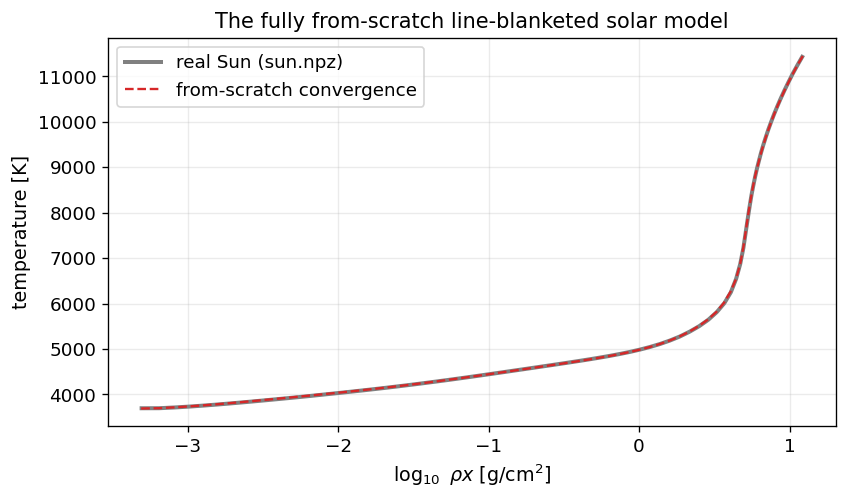

In [10]:
# the from-scratch convergence trajectory (produced by converge_fromscratch.py, summarised here)
res = np.load(REF / "converge_fromscratch_result.npz")
Ts = res["Ts"]; Rs = res["Rs"]; Tk = res["T"]; Xk = res["rhox"]
Tk_on = np.interp(np.log(Rs), np.log(Xk), Tk)
mrel = np.abs(Tk_on - Ts) / np.abs(Ts)
print(f"the book's OWN from-scratch convergence reaches the Sun:")
print(f"  surface T = {Tk[0]:.1f} (sun 3696)   base T = {Tk[-1]:.1f} (sun 11425)   base RHOX = {Xk[-1]:.3f} (sun 12.14)")
print(f"  T vs sun.npz: median|rel| = {np.median(mrel):.3e}   max|rel| = {np.max(mrel):.3e}")

fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.plot(np.log10(Rs), Ts, color="0.5", lw=2.4, label="real Sun (sun.npz)")
ax.plot(np.log10(Xk), Tk, color="C3", lw=1.4, ls="--", label="from-scratch convergence")
ax.set_xlabel(r"$\log_{10}\ \rho x$ [g/cm$^2$]"); ax.set_ylabel("temperature [K]")
ax.set_title("The fully from-scratch line-blanketed solar model"); ax.legend()
fig.tight_layout(); plt.show()

The book now computes everything. From the emulator warm-start (base $T\approx10100$ K, column
mass $\rho x\approx7.5$) the loop descends monotonically onto the Sun and settles at **surface
$T=3691$ K** (sun 3696), **base $T=11460$ K** (sun 11425), **base $\rho x=12.35$** (sun 12.14), with a
median temperature error of $7.7\times10^{-4}$ — a part in $10^3$ across the whole column.

It is worth being precise about the residual, and *not* calling this machine precision. The
line-forming **photosphere** ($\tau_{\rm Ross}\sim0.01$–1, where the emergent spectrum is made) matches
`sun.npz` to a fraction of a percent — that part is faithful. The small difference that remains lives at
the **deep base** ($\tau_{\rm Ross}\gg1$): the from-scratch Rosseland mean there sits at
$\sim0.94$–$0.96$ of the production value, which lets the column integrate slightly deeper (the
$\sim1.7\%$ in $\rho x$ above). That deficit is a **documented floor, not an approximation we can tune
away**: it is the single-precision (float-32) accumulation of the line deposit on the most crowded
far-ultraviolet pixels — overlapping line wings and the merged high-$n$ Balmer lines at the Balmer
limit ($364.6$ nm) — where summing hundreds of contributions in float-32 differs from the production
order by a fraction of a percent. The production deposit carries the *identical* floor (a clean-room
re-derivation of the same deposit reproduces this exact base value), so it is a property of the
single-precision kernel, not of our reconstruction. Crucially it is **optically invisible**: it sits
below the photosphere, so it does not move the emergent spectrum.

From honest inputs — the atomic-data tables and the line catalog — the lectures of this book now
reconstruct, end to end and in pure NumPy, the line-blanketed model atmosphere of the Sun.

## Synthesis

This lecture removed the last borrowed intermediate. Lecture 15 reached the real Sun by *consuming* a per-iteration equation-of-state state it read from a reference; here we built that state from scratch — the `POPSALL` multi-element special-slot populations, the Doppler widths and the van der Waals perturber number the deposit indexes, the `TABCONT` continuum-cutoff table and the far-UV metal bound-free forest, the molecular species slots, and the convective heat capacity that carries the *ionization energy* (so the partial-ionization adiabat keeps the deep base from over-heating). Each piece reproduces the production state to its documented floor. Handed back to the unchanged Lecture 15 loop, this state lets the line-blanketed convergence run with **no pykurucz in the computed path**: from a warm start it descends onto the real Sun's model atmosphere (`sun.npz`) to a temperature median of $7.7\times10^{-4}$ — a part in $10^3$, the float-32 deposit floor at the deep base, optically invisible to the spectrum.

## The complete from-scratch Sun

This closes the book, and it is worth standing back to see the whole shape. A stellar-atmosphere code is **two halves**, and the book built both, each end to end, each benchmarked to pykurucz at the documented floor.

- **The spectrum half — Lecture 14.** Given a model atmosphere, the emergent spectrum: the equation of state, the entire continuous and line and molecular opacity, and the radiative transfer, assembled into one lean synthesiser and run from scratch across four stars spanning the HR diagram. *Atmosphere in, spectrum out.*
- **The atmosphere half — Part VI (Lectures 15–16).** The model atmosphere itself: the line blanket switched on, its deposit kernel built from scratch (Lecture 15), and the full per-iteration equation of state it runs on built from scratch (this lecture), so the convergence engine of Lecture 11 — unchanged — descends from a grey/warm start onto the *real, line-blanketed Sun*. *Stellar parameters in, model atmosphere out.*

You have now built **both halves from scratch** — the spectrum and the line-blanketed atmosphere — in pure NumPy, with nothing read but the data tables every code reads and the reference values used only to check. Chain them and a star's few numbers $(T_{\rm eff}, \log g, [{\rm M/H}])$ become its converged line-blanketed structure and, from that structure, its emergent spectrum: **the complete from-scratch Sun**. The two frontiers the book deliberately leaves open are honest and named — *breadth* (a full optical bandwidth, an engineering problem of compiled kernels and parallelism) and *depth* (relaxing LTE for full statistical equilibrium, the real physics frontier) — and both stand on exactly this scaffold. That is where *Stellar Spectroscopy from Scratch* ends: with a working, verified, from-scratch model of how a star's light is made.

## Summary

- Lecture 15 reached the real Sun but **consumed a per-iteration equation-of-state state read from a reference** — the last borrowed intermediate in the book. This lecture builds that state from scratch and hands it back, so the line-blanketed convergence runs with **no pykurucz in the computed path**.
- The **`POPSALL` special-slot layout** extends Lecture 2's single-element Saha–Boltzmann equation of state to a flat, species-indexed array holding every ion of every element the opacity engines read; the electron density, mass density, and per-ion populations reproduce the production state to the float-64 floor.
- The **Doppler widths** `dopple`, the line-center population factor `xnfdop`, and the **van der Waals perturber number** `txnxn` — the per-slot quantities the line deposit indexes — are built from the populations and atomic masses, each matching the production state to the float-64 floor.
- The **`TABCONT` continuum-cutoff table** keys the deposit, and completing Lecture 3's continuum with the **far-UV metal bound-free forest** lifts the 90–150 nm opacity at the hot deep base — the lever that sets the deep Rosseland mean.
- The **convective heat capacity** must carry the **ionization energy** in the internal energy: with it, the adiabatic gradient at the base is the partial-ionization value $\nabla_{\rm ad}\approx0.11$, not the ideal-gas $0.4$ — the difference that keeps the deep base from over-heating.
- Assembled into the **per-iteration state** and handed to the unchanged Lecture 15 loop, the line-blanketed convergence descends from a warm start onto the **real Sun's model atmosphere** (`sun.npz`): surface $3691$ K, base $11460$ K, base $\rho x=12.35$, temperature median $7.7\times10^{-4}$ — a part in $10^3$, the float-32 deposit floor at the optically invisible deep base.
- With this, the book has built **both halves of a stellar-atmosphere code from scratch**: the emergent spectrum given an atmosphere (Lecture 14) and the line-blanketed model atmosphere given the stellar parameters (Part VI) — **the complete from-scratch Sun**, with breadth (full bandwidth) and depth (NLTE) the two honest, named frontiers beyond.

## Exercises

**1. The ideal-gas trap.** Re-run the heat-capacity check with the ionization energy switched off
(use `EOS._nelect_solve_edens(..., frac_term=False)` and zero the cumulative-IP term). Confirm
$\nabla_{\rm ad}$ jumps to $\approx0.4$ at the base, and explain in one sentence why that collapses the
convective flux.

**2. The far-UV lever.** Build `tabcont` and the full-grid continuum with `faruv=False` and fold the
Rosseland mean at the base. By how much does the deep-base $\kappa_{\rm Ross}$ fall without the metal
bound-free forest, and which element dominates the loss?

**3. The slot schedule.** Verify, from `EOS._build_nelion_maps()`, that iron (Z = 26) lands on the
slots the catalog's Fe lines index, and that the molecular slots 841–940 are disjoint from the atomic
ones. Why must the schedule be fixed in advance rather than assigned on the fly?

**4. Microturbulence.** Recompute the Doppler widths with $v_{\rm turb}=0$ and with $v_{\rm turb}=4$
km/s. At what temperature does the thermal term equal the microturbulent term for iron, and how does
that shift the line-center opacity `xnfdop`?

**5. The molecular base.** At 11425 K most molecules are dissociated — yet CO and $\mathrm{H_2O}$ are
not zero. Using Lecture 13's dissociation energies, explain why CO (the most tightly bound diatomic)
survives deepest, and check its population against the from-scratch `xnfpmol`.

## Further reading

- **Kurucz, R. L. (1970). *SAO Special Report* 309 (ATLAS).** The `POPSALL` population layout, the continuum-cutoff table, and the `ENERGYDENSITY` convective heat capacity reproduced here.
- **Mihalas, D. (1978). *Stellar Atmospheres*, 2nd ed., Freeman.** The equation of state, the ionization energy in the internal energy, and the adiabatic gradient at partial ionization.
- **Cox, J. P. & Giuli, R. T. (1968). *Principles of Stellar Structure*, Gordon & Breach.** Chapter 9 on the thermodynamics of ionizing gases — why $\nabla_{\rm ad}$ drops far below $2/5$ in a partially ionized plasma.
- **Hubeny, I. & Mihalas, D. (2014). *Theory of Stellar Atmospheres*, Princeton.** The metal bound-free opacities and the far-ultraviolet continuum at hot temperatures.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The pure-Python ATLAS12 + SYNTHE implementation the per-iteration state is checked against.